In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils.helpers as hlp
from samplers.linear_models import BayesianRegression

In [2]:
seed = 42
rng = np.random.default_rng(seed)

In [3]:
def data_generator(
    num_data=1000, beta_star=None,
    sigma=0.5, seed=seed
):
    """ 
    X: (num_data, dim), y: (num_data,)
    beta_star: (dim,)
    """
    beta_star = np.asarray(beta_star)
    dim = beta_star.size
    rng = np.random.default_rng(seed)
    X = rng.standard_normal(size=(num_data, dim))
    y = X @ beta_star + sigma * rng.standard_normal(size=num_data)
    return X, y

# 2D Experiments With Synthetic Data

In [4]:
# True Parameters 
beta_star = [1.0, 1.0]
# Generate Data
X, y = data_generator(
    num_data=10000, beta_star=beta_star, sigma=0.5
)

## Ordinary Least Squares Estimates

In [5]:
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
print("OLS estimate:", beta_ols)

OLS estimate: [0.98387736 0.99337022]


## Prior Distributions  

We consider the prior distribution of the regression coefficients $\mathbf{\beta}=[\beta_0, \beta_1]^{\top}$ is the uniform distribution over the $\ell_p$ ball,  

$B_{O}(0,s)=\{\beta\in\mathbb{R}^2: \|\mathbf{\beta}\|_{\ell_p}\le s\}$. 

where, $s=t\|\beta^{OLS}\|_p$ for $t\in[0,1]$ is the boundary. 

[Code accepts only $p=1,2$]  

### $\ell_2$ Prior with $s=\frac45\beta^{OLS}$  

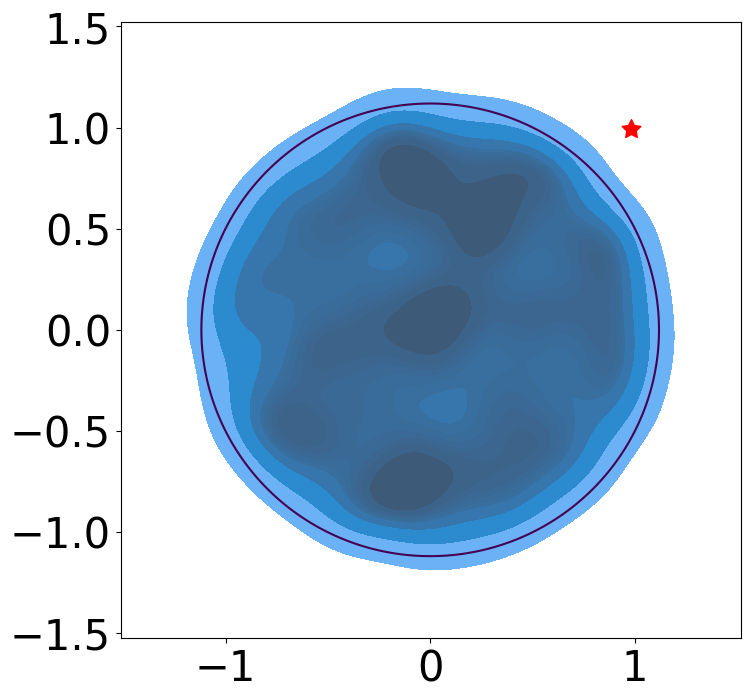

In [7]:
lp = 2
s = 0.8*np.linalg.norm(beta_ols, ord=lp)
prior_dist = hlp.priors(dim=2,s=s, p=lp, N=5000, rng=rng)
beta_x=prior_dist.T[0]
beta_y=prior_dist.T[1]

X1 = np.linspace(-1.5, 1.5, 1000)
Y = np.linspace(-1.5, 1.5, 1000)
xx, yy = np.meshgrid(X1, Y)
zz = np.power(
    np.power(np.abs(xx), lp) + np.power(np.abs(yy), lp), 1/lp
)
fig = plt.figure(figsize=(8, 8))
plt.contour(X1, Y, zz, [s])
sns.kdeplot(
    x=beta_x, y=beta_y, fill=True, levels=10
)
plt.scatter(beta_ols[0], beta_ols[1], c='r', s=200, label='OLS Estimate', marker=(5,1))
plt.tick_params(labelsize=30)
plt.show()

## Sampling from the posterior distribution

In [8]:
model = BayesianRegression(X=X, y=y, lp=2, s=s)

In [9]:
history_all, beta_mean_all = model.sample_parameters(
    method='dpsgld', iterations=100
)

100%|██████████| 100/100 [00:01<00:00, 59.03it/s]


In [10]:
beta_mean_all.shape

(101, 2, 100)

In [11]:
history_all.shape

(101, 8, 2, 100)

In [12]:
my_chain = model.sample_parameters(method='mysgld', iterations=100)

100%|██████████| 100/100 [00:00<00:00, 687.05it/s]


In [13]:
my_chain.shape

(101, 2, 100)